In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [4]:
# 1. SETTINGS & STYLING
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Function to format Y-axis as Millions
def millions(x, pos):
    return f'${x/1e6:.1f}M'
formatter = FuncFormatter(millions)

In [6]:
df_sales = pd.read_excel('D:\sales analyis\Regional Sales Dataset.xlsx', sheet_name='Sales Orders')
df_customers = pd.read_excel('D:\sales analyis\Regional Sales Dataset.xlsx', sheet_name="Customers")
df_regions = pd.read_excel('D:\sales analyis\Regional Sales Dataset.xlsx' ,sheet_name= 'Regions')
df_state_regions = pd.read_excel('D:\sales analyis\Regional Sales Dataset.xlsx', sheet_name='State Regions',skiprows=1)
df_products = pd.read_excel('D:\sales analyis\Regional Sales Dataset.xlsx', sheet_name= 'Products')
df_budgets_2017 = pd.read_excel('D:\sales analyis\Regional Sales Dataset.xlsx', sheet_name='2017 Budgets')

df_budgets_2017.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [8]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [9]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [11]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [8]:
df_state_regions.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [12]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [13]:
# 2. Data Cleaning & Preparation
# The State Regions file has headers in the first row
df_state_regions.columns = df_state_regions.iloc[0]


In [14]:
#Convert dates to datetime objects
df_sales['OrderDate'] = pd.to_datetime(df_sales['OrderDate'])

In [17]:
# Merge Sales with Customers
master_df = df_sales.merge(df_customers, left_on='Customer Name Index', right_on='Customer Index', how='left')

# Merge with Products
master_df = master_df.merge(df_products, left_on='Product Description Index', right_on='Index', how='left')

# Merge with Regions (Cities)
master_df = master_df.merge(df_regions, left_on='Delivery Region Index', right_on='id', how='left')

In [22]:
master_df['Total Line Cost'] = master_df['Order Quantity'] * master_df['Total Unit Cost']
master_df['Profit'] = master_df['Line Total'] - master_df['Total Line Cost']
master_df['Profit Margin %'] = (master_df['Profit'] / master_df['Line Total']) * 100

In [41]:
# 2. Fix the State Regions headers by position (Safest Method)
# We ignore the current names and just say: Column 1 is Code, Column 2 is State, Column 3 is Region
df_state_regions.columns = ['State Code', 'State', 'Region']
# Remove the first row if it contains the words "State", "Region"
if 'State' in str(df_state_regions.iloc[0, 1]):
    state_regions = df_state_regions.drop(0).reset_index(drop=True)

In [43]:
#Clean up spaces in the matching columns
master_df['state'] = master_df['state'].str.strip()
df_state_regions['State'] = df_state_regions['State'].str.strip()

# Join the Region information
master_df = pd.merge(master_df, df_state_regions[['State', 'Region']], 
                     left_on='state', right_on='State', how='left')

In [23]:
#5. GENERATE VISUALIZATIONS
sns.set_theme(style="whitegrid")

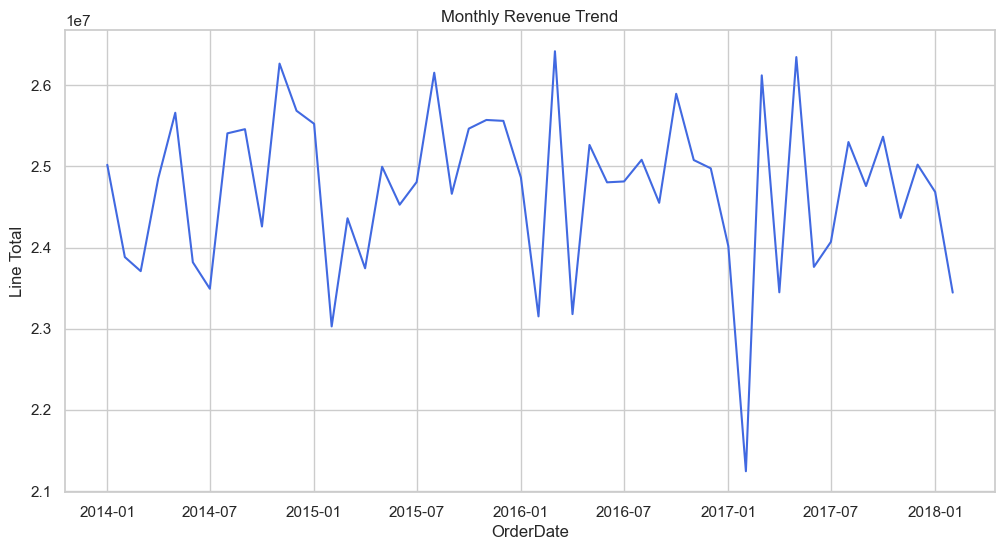

In [29]:
# Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales = master_df.groupby(master_df['OrderDate'].dt.to_period('M'))['Line Total'].sum().reset_index()
monthly_sales['OrderDate'] = monthly_sales['OrderDate'].dt.to_timestamp()
sns.lineplot(data=monthly_sales, x='OrderDate', y='Line Total', color='royalblue')
plt.title('Monthly Revenue Trend')
plt.savefig('sales_trend.png')

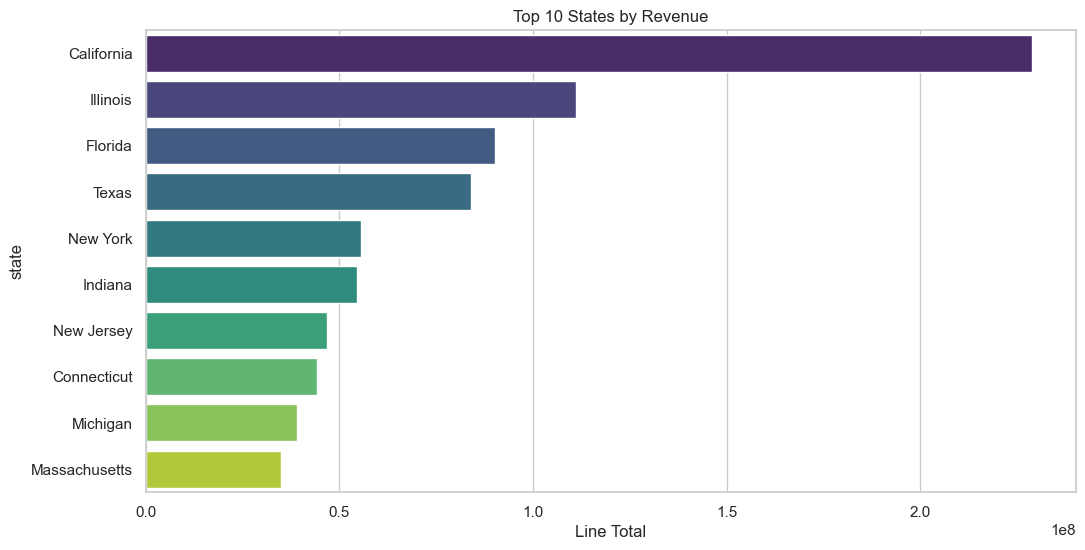

In [28]:
# Top 10 States
plt.figure(figsize=(12, 6))
state_sales = master_df.groupby('state')['Line Total'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=state_sales, x='Line Total', y='state', palette='viridis')
plt.title('Top 10 States by Revenue')
plt.savefig('top_states.png')

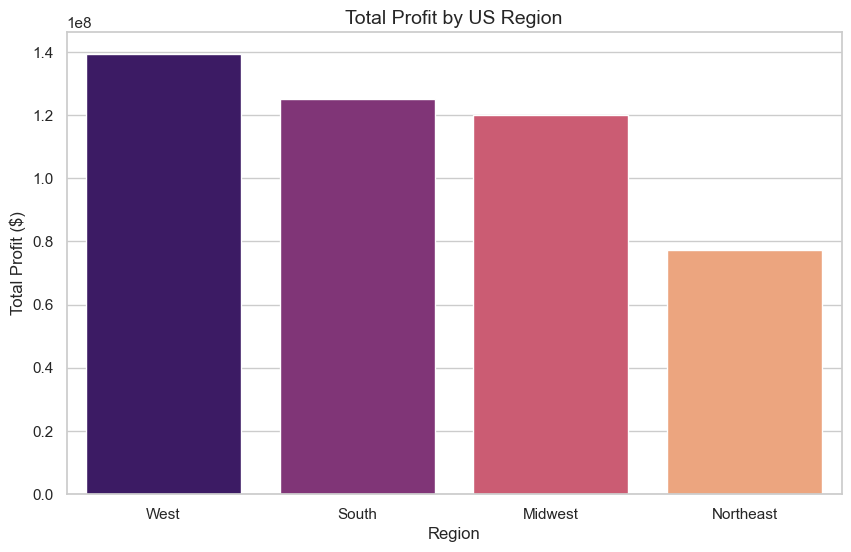

<Figure size 1200x600 with 0 Axes>

In [46]:
  # 5. Visualization Total profit by us resgion
plt.figure(figsize=(10, 6))
    
# Sum profit by Region and sort
region_profit = master_df.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()
    
sns.barplot(data=region_profit, x='Region', y='Profit', palette='magma')
plt.title('Total Profit by US Region', fontsize=14)
plt.ylabel('Total Profit ($)')
plt.show() # Use plt.show() to see it in your notebook or save it:
plt.savefig('profit_by_region.png')
  

In [47]:
# Summary Output
print(f"--- Analysis Complete ---")
print(f"Total Revenue: ${master_df['Line Total'].sum():,.2f}")
print(f"Total Profit:  ${master_df['Profit'].sum():,.2f}")
print(f"Avg Margin:    {master_df['Profit Margin %'].mean():.2f}%")

--- Analysis Complete ---
Total Revenue: $1,235,968,899.00
Total Profit:  $461,772,559.92
Avg Margin:    37.36%
